# Atividade de vendas no Brasil

## Entregável 1

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/vendas_brasil_1.csv')

# Cria os arrays
preco_unitario = df['preco_unitario'].to_numpy()
custo_unitario = df['custo_unitario'].to_numpy()
quantidade = df['quantidade'].to_numpy()
desconto_pct = df['desconto_pct'].to_numpy()
receita_total = df['receita_total'].to_numpy()
frete  = df['frete'].to_numpy()

print(">> A) Arrays")
print("Preço unitário:", preco_unitario)
print("Custo unitário:", custo_unitario)
print("Quantidade:", quantidade)
print("Desconto (%):", desconto_pct)
print("Receita total:", receita_total)
print("Frete:", frete)
print("")

# Calcula novas informações
valor_bruto = preco_unitario * quantidade
valor_desconto = valor_bruto * (desconto_pct / 100.0)
custo_total = (custo_unitario * quantidade)
lucro_estimado = receita_total - custo_total

print(">> B) Informações com operações vetorizadas")
print("Valor bruto:", valor_bruto[:5])
print("Valor do desconto:", valor_desconto[:5])
print("Custo total:", custo_total[:5])
print("Lucro estimado:", lucro_estimado)
print("")

# Cria máscaras booleanas
# 1. Vendas com receita acima da média
media_receita = np.mean(receita_total)
vendas_acima_media = receita_total[receita_total > media_receita]

# 2. Vendas com prejuízo (Lucro estimado menor que zero)
vendas_prejuizo = lucro_estimado[lucro_estimado < 0]

# 3. Vendas com desconto alto (Desconto acima da média de descontos)
media_desconto = np.mean(desconto_pct)
vendas_desconto_alto = desconto_pct[desconto_pct > media_desconto]

print(">> C) Máscaras")
print(f"Vendas acima da receita média: {len(vendas_acima_media)}")
print(f"Vendas que geraram prejuízo: {len(vendas_prejuizo)}")
print(f"Vendas com desconto alto: {len(vendas_desconto_alto)}")
print("")

# Calcula agregações
receita_media = np.mean(receita_total)
maior_receita = np.max(receita_total)
menor_receita = np.min(receita_total)
lucro_medio = np.mean(lucro_estimado)
qtd_prejuizo = len(vendas_prejuizo)

print(">> D) Agregações")
print(f"Receita média: R$ {receita_media:.2f}")
print(f"Maior receita: R$ {maior_receita:.2f}")
print(f"Menor receita: R$ {menor_receita:.2f}")
print(f"Lucro médio: R$ {lucro_medio:.2f}")
print(f"Quantidade de vendas com prejuízo: {qtd_prejuizo}")


>> A) Arrays
Preço unitário: [ 739.39  187.48   76.11 ...   55.15  197.09 1057.41]
Custo unitário: [561.75 135.15  61.4  ...  36.94 167.23 870.69]
Quantidade: [10  5 14 ...  7  7  4]
Desconto (%): [ 5.2  0.6  0.7 ...  0.  10.9 10. ]
Receita total: [6933.48  930.28 1058.5  ...  384.44 1960.18 3795.73]
Frete: [ 8.68   nan  7.98 ... 85.35 30.99 27.23]

>> B) Informações com operações vetorizadas
Valor bruto: [7393.9   937.4  1065.54 1604.46  133.92]
Valor do desconto: [384.4828    5.6244    7.45878   9.62676  26.1144 ]
Custo total: [5617.5   675.75  859.6   973.83  107.25]
Lucro estimado: [1315.98  254.53  198.9  ...  125.86  789.57  312.97]

>> C) Máscaras
Vendas acima da receita média: 9236
Vendas que geraram prejuízo: 2168
Vendas com desconto alto: 17853

>> D) Agregações
Receita média: R$ 1891.69
Maior receita: R$ 58430.28
Menor receita: R$ 3.70
Lucro médio: R$ 513.19
Quantidade de vendas com prejuízo: 2168


### Conclusões

Com uma receita média de 1891, menor receita de 3,70 e maior receita de 58430,28, percebemos que há grandes outliers, mostrando uma variedade alta de preços de produtos.

Existem 2168 produtos que geraram prejuízo, e necessitam de uma análise mais profunda para entender o motivo e projetar uma solução para mitigar esses números.



## Entregável 2

In [ ]:
# A) Exploração dos dados
print(">> Primeiras Linhas")
display(df.head())

print("\n>> Informações")
df.info()

print("\n>> Descrição do dataset")
display(df.describe())

print("\n>> Formato do dataset")
print(df.shape)

print("\n>> Dados faltantes")
print(df.isna().sum())

>> Primeiras Linhas


,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco
0,2022-04-13,4,Rio de Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,10,5.2,6933.48,8.68,4.92,5.0,False,True,False,False
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,5,0.6,930.28,NaN,4.98,19.0,True,False,False,False
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,14,0.7,1058.50,7.98,3.47,NaN,True,True,False,False
3,2022-04-17,4,Fortaleza,Site Web,Vestuário,Calça Jeans,Carla Mendes,Bronze,145.86,88.53,...,11,0.6,1592.43,20.49,4.50,16.0,False,True,False,False
4,2022-03-13,3,Belo Horizonte,App Mobile,Esportes,Bicicleta,João Vieira,Bronze,133.92,107.25,...,1,19.5,107.64,22.89,3.49,13.0,False,True,False,False



>> Informações
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37617 entries, 0 to 37616
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   data_venda          37617 non-null  object 
 1   mes                 37617 non-null  int64  
 2   cidade              37617 non-null  object 
 3   canal_venda         37567 non-null  object 
 4   categoria           37617 non-null  object 
 5   produto             37617 non-null  object 
 6   vendedor            37577 non-null  object 
 7   fidelidade_cliente  37617 non-null  object 
 8   preco_unitario      37617 non-null  float64
 9   custo_unitario      37617 non-null  float64
 10  margem_pct          37535 non-null  float64
 11  quantidade          37617 non-null  int64  
 12  desconto_pct        37617 non-null  float64
 13  receita_total       37617 non-null  float64
 14  frete               35738 non-null  float64
 15  avaliacao_cliente   34662 non-null  f

,mes,preco_unitario,custo_unitario,margem_pct,quantidade,desconto_pct,receita_total,frete,avaliacao_cliente,prazo_entrega_dias
count,37617.000000,37617.000000,37617.000000,37535.000000,37617.000000,37617.000000,37617.000000,35738.000000,34662.000000,36113.000000
mean,6.517691,253.214933,183.620999,22.714776,7.481750,9.494048,1891.688173,29.885737,3.912094,10.017113
std,3.439296,316.742367,231.376757,8.670213,4.322273,9.097484,2972.445759,24.765161,0.932256,5.477487
min,1.000000,4.940000,3.010000,-0.570000,1.000000,0.000000,3.700000,3.750000,1.000000,1.000000
25%,4.000000,68.960000,49.550000,16.380000,4.000000,0.300000,364.280000,12.190000,3.490000,5.000000
50%,7.000000,111.300000,80.990000,22.700000,7.000000,9.000000,789.570000,22.250000,4.010000,10.000000
75%,9.000000,257.680000,186.570000,29.250000,11.000000,19.000000,1853.210000,39.480000,4.520000,15.000000
max,12.000000,9008.600000,6578.260000,44.270000,161.000000,26.000000,58430.280000,243.820000,5.000000,19.000000



>> Formato do dataset
(37617, 21)

>> Dados faltantes
data_venda               0
mes                      0
cidade                   0
canal_venda             50
categoria                0
produto                  0
vendedor                40
fidelidade_cliente       0
preco_unitario           0
custo_unitario           0
margem_pct              82
quantidade               0
desconto_pct             0
receita_total            0
frete                 1879
avaliacao_cliente     2955
prazo_entrega_dias    1504
devolucao                0
entrega_no_prazo         0
alta_temporada           0
flag_outlier_preco       0
dtype: int64


1. Existem 37617 linhas (registros) e 21 colunas no dataset.

2. Existem dados faltantes nas seguintes colunas:
* canal_venda: 50
* vendedor: 40
* margem_pct: 82
* frete: 1879
* avaliacao_cliente: 2955
* prazo_entrega_dias: 1504

3. mes, preco_unitario, custo_unitario, margem_pct, quantidade, desconto_pct, receita_total, frete, avaliacao_cliente e prazo_entrega_dias

4. cidade, canal_venda, categoria, produto, vendedor, fidelidade_cliente, devolucao, entrega_no_prazo, alta_temporada e flag_outlier_preco (não tenho certeza se data contaria como uma categoria)



In [ ]:
# >> B) Limpeza e tratamento

# 1. Converte a coluna data_venda para formato datetime
df['data_venda'] = pd.to_datetime(df['data_venda'], format='mixed')

# 2.1 Padroniza variações de nomes de cidades
mapeamento_cidades = {
    'RIO': 'RIO DE JANEIRO',
    'RJ': 'RIO DE JANEIRO',
    'SAO PAULO': 'SÃO PAULO',
    'S. PAULO': 'SÃO PAULO',
    'SP': 'SÃO PAULO',
    'B. HORIZONTE': 'BELO HORIZONTE',
    'BH': 'BELO HORIZONTE',
    'CURTIBA': 'CURITIBA',
    'SLAVADOR': 'SALVADOR',
}

df['cidade'] = df['cidade'].str.strip().str.upper()
df['cidade'] = df['cidade'].replace(mapeamento_cidades)
df['cidade'] = df['cidade'].str.title()

# 2.2 Padroniza variações de canais de vendas
mapeamento_canais = {
    'SiteWeb': 'Site Web',
    'Site web': 'Site Web',
    'site web': 'Site Web',
    'app mobile': 'App Mobile',
    'App mobile': 'App Mobile',
    'APP Mobile': 'App Mobile',
    'APP mobile': 'App Mobile',
    'Loja Fisica': 'Loja Física',
    'Loja fisica': 'Loja Física',
    'loja Física': 'Loja Física',
    'loja física': 'Loja Física'
}

df['canal_venda'] = df['canal_venda'].astype(str).str.strip()
df['canal_venda'] = df['canal_venda'].replace(mapeamento_canais)

# 3.1 Preenche faltantes do frete com zero
df['frete'] = df['frete'].fillna(0)

# 3.2 Preenche faltantes da avaliação com a média para não causar distorções na análise
media_avaliacao = df['avaliacao_cliente'].mean()
df['avaliacao_cliente'] = df['avaliacao_cliente'].fillna(media_avaliacao)

# 3.3 Preenche faltantes do prazo de entrega com a mediana de dias
mediana_prazo = df['prazo_entrega_dias'].median()
df['prazo_entrega_dias'] = df['prazo_entrega_dias'].fillna(mediana_prazo).astype(int)

1. De início, o formato 'Y-m-d' estava resultando em erro em todas as linhas, e testando outros formatos também deu o mesmo problema. Usar o formato mixed foi o suficiente para resolver isso.

2. Escolhi a coluna cidade para padronizar. Olhando o filtro da coluna no CSV importado no Excel, vi que haviam de 2 a 3 variações de escrita das cidades, então usei um mapeamento para igualar as variações de cada cidade a um único nome padronizado em caixa alta e também converti a coluna para caixa alta, para evitar problemas caso houvessem cases diferentes também.

3. Preenchi os valores faltantes da coluna frete com zero, assumindo que os que não foram incluidos não foram pagos pela empresa ou foram deixados vazios para não serem contabilizados. Já os valores da avaliação do cliente e de prazo de entrega foram preenchidos com a média da avaliação e mediana de dias, respectivamente, para evitar grandes distorções na análise.

In [ ]:
# >> C) Criação de novas colunas

# 1. Ano da venda
df['ano_venda'] = df['data_venda'].dt.year

# 2. Mês da venda
df['mes_venda'] = df['data_venda'].dt.month

meses = {
    1: 'Janeiro', 2: 'Fevereiro', 3: 'Março', 4: 'Abril', 5: 'Maio', 6: 'Junho',
    7: 'Julho', 8: 'Agosto', 9: 'Setembro', 10: 'Outubro', 11: 'Novembro', 12: 'Dezembro'
}

df['mes_venda'] = df['mes_venda'].map(meses)

# 3. Faixa de receita
df['faixa_receita'] = df['receita_total'].apply(lambda x: 'Alta' if x > receita_media else 'Padrão')

print("Novas colunas:")
display(df[['ano_venda', 'mes_venda', 'receita_total', 'faixa_receita']].head())

# >> D. Filtros

print(f"\n1. Vendas com receita total acima da média (R${receita_media:.2f}):")
filtro_alta_receita = df[df['receita_total'] > receita_media]
display(filtro_alta_receita)

print("\n2. Vendas que tiveram devolução:")
filtro_devolucao = df[df['devolucao'] == True]
display(filtro_devolucao)

print("\n3. Vendas pertencentes à categoria 'Eletrônicos':")
filtro_categoria = df[df['categoria'] == 'Eletrônicos']
display(filtro_categoria)

# >> E) Agrupamentos com groupby

# 1. Receita Total por Categoria
receita_por_categoria = df.groupby('categoria')['receita_total'].sum().sort_values(ascending=False)
print("\nReceita Total por Categoria:\n", receita_por_categoria)

# 2. Quantidade de Vendas por Canal
vendas_por_canal = df.groupby('canal_venda')['quantidade'].sum().sort_values(ascending=False)
print("\nQuantidade de Vendas por Canal:\n", vendas_por_canal)

# 3. Receita Total por Cidade
receita_por_cidade = df.groupby('cidade')['receita_total'].sum().sort_values(ascending=False)
print("\nReceita Total por Cidade:\n", receita_por_cidade)



Novas colunas:


,ano_venda,mes_venda,receita_total,faixa_receita
0,2022,Abril,6933.48,Alta
1,2023,Março,930.28,Padrão
2,2022,Setembro,1058.50,Padrão
3,2022,Abril,1592.43,Padrão
4,2022,Março,107.64,Padrão



1. Vendas com receita total acima da média (R$1891.69):


,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,ano_venda,mes_venda,faixa_receita
0,2022-04-13,4,Rio De Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,8.68,4.92,5,False,True,False,False,2022,Abril,Alta
11,2022-11-27,11,São Paulo,Site Web,Esportes,Raquete,João Vieira,Prata,130.74,101.92,...,6.80,4.52,14,False,False,True,False,2022,Novembro,Alta
15,2022-04-10,4,Salvador,Marketplace,Eletrônicos,Smartphone,Ana Lima,Bronze,1213.88,843.05,...,47.18,3.52,12,False,False,False,True,2022,Abril,Alta
17,2022-05-11,5,Belo Horizonte,App Mobile,Eletrônicos,Smartwatch,Elisa Costa,Prata,732.37,536.37,...,48.72,2.94,4,False,True,False,False,2022,Maio,Alta
20,2022-12-10,12,Recife,Site Web,Eletrônicos,Smartphone,Inês Nunes,Prata,603.40,394.18,...,68.85,4.47,13,False,True,True,False,2022,Dezembro,Alta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37593,2023-12-31,2,Manaus,Site Web,Eletrônicos,Tablet,Gabi Alves,Ouro,565.19,385.88,...,77.13,4.02,17,False,False,False,False,2023,Dezembro,Alta
37603,2023-12-31,9,Rio De Janeiro,App Mobile,Eletrônicos,Tablet,Inês Nunes,Prata,963.50,608.11,...,18.19,3.49,3,False,True,False,True,2023,Dezembro,Alta
37605,2023-12-31,3,Fortaleza,Marketplace,Esportes,Tapete de Yoga,Carla Mendes,Bronze,352.25,256.20,...,42.94,3.52,7,False,True,False,False,2023,Dezembro,Alta
37615,2023-12-31,11,São Paulo,Site Web,Esportes,Tapete de Yoga,João Vieira,Bronze,197.09,167.23,...,30.99,3.50,6,False,True,True,False,2023,Dezembro,Alta



2. Vendas que tiveram devolução:


,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,ano_venda,mes_venda,faixa_receita
1,2023-03-12,3,Manaus,Site Web,Vestuário,Camiseta,Elisa Costa,Bronze,187.48,135.15,...,0.00,4.980000,19,True,False,False,False,2023,Março,Padrão
2,2022-09-28,9,Goiânia,App Mobile,Vestuário,Tênis,João Vieira,Bronze,76.11,61.40,...,7.98,3.470000,10,True,True,False,False,2022,Setembro,Padrão
7,2023-09-07,9,Manaus,App Mobile,Alimentação,Mel Orgânico,Inês Nunes,Prata,35.72,21.62,...,24.98,3.030000,18,True,False,False,False,2023,Setembro,Padrão
18,2023-10-24,10,Manaus,Site Web,Vestuário,Camiseta,Carla Mendes,Prata,65.73,41.26,...,56.61,3.912094,16,True,True,False,False,2023,Outubro,Padrão
21,2023-05-07,5,São Paulo,Loja Física,Eletrônicos,Smartwatch,Gabi Alves,Bronze,892.83,660.58,...,9.89,1.050000,18,True,True,False,True,2023,Maio,Alta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37522,2023-12-31,11,Salvador,Marketplace,Esportes,Bicicleta,Carla Mendes,Bronze,195.87,161.39,...,6.95,2.950000,7,True,True,True,False,2023,Dezembro,Alta
37525,2023-12-31,11,Curitiba,Loja Física,Esportes,Luva de Box,Ana Lima,Prata,248.42,183.21,...,8.57,2.040000,13,True,True,True,False,2023,Dezembro,Alta
37533,2023-12-31,5,Belo Horizonte,App Mobile,Alimentação,Granola,Henrique Dias,Prata,48.60,36.51,...,13.15,4.490000,14,True,True,False,False,2023,Dezembro,Padrão
37583,2023-12-31,2,Manaus,Loja Física,Eletrônicos,Smartwatch,Henrique Dias,Bronze,846.16,697.37,...,14.03,1.000000,10,True,True,False,True,2023,Dezembro,Alta



3. Vendas pertencentes à categoria 'Eletrônicos':


,data_venda,mes,cidade,canal_venda,categoria,produto,vendedor,fidelidade_cliente,preco_unitario,custo_unitario,...,frete,avaliacao_cliente,prazo_entrega_dias,devolucao,entrega_no_prazo,alta_temporada,flag_outlier_preco,ano_venda,mes_venda,faixa_receita
0,2022-04-13,4,Rio De Janeiro,App Mobile,Eletrônicos,Notebook,Bruno Souza,Diamante,739.39,561.75,...,8.68,4.92,5,False,True,False,False,2022,Abril,Alta
15,2022-04-10,4,Salvador,Marketplace,Eletrônicos,Smartphone,Ana Lima,Bronze,1213.88,843.05,...,47.18,3.52,12,False,False,False,True,2022,Abril,Alta
17,2022-05-11,5,Belo Horizonte,App Mobile,Eletrônicos,Smartwatch,Elisa Costa,Prata,732.37,536.37,...,48.72,2.94,4,False,True,False,False,2022,Maio,Alta
20,2022-12-10,12,Recife,Site Web,Eletrônicos,Smartphone,Inês Nunes,Prata,603.40,394.18,...,68.85,4.47,13,False,True,True,False,2022,Dezembro,Alta
21,2023-05-07,5,São Paulo,Loja Física,Eletrônicos,Smartwatch,Gabi Alves,Bronze,892.83,660.58,...,9.89,1.05,18,True,True,False,True,2023,Maio,Alta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37589,2023-12-31,4,Rio De Janeiro,App Mobile,Eletrônicos,Fone Bluetooth,Fábio Ramos,Bronze,899.09,734.88,...,20.08,4.04,8,True,False,False,True,2023,Dezembro,Alta
37593,2023-12-31,2,Manaus,Site Web,Eletrônicos,Tablet,Gabi Alves,Ouro,565.19,385.88,...,77.13,4.02,17,False,False,False,False,2023,Dezembro,Alta
37600,2023-12-31,12,Fortaleza,App Mobile,Eletrônicos,Tablet,Henrique Dias,Ouro,212.67,167.18,...,7.09,2.05,6,False,True,True,False,2023,Dezembro,Padrão
37603,2023-12-31,9,Rio De Janeiro,App Mobile,Eletrônicos,Tablet,Inês Nunes,Prata,963.50,608.11,...,18.19,3.49,3,False,True,False,True,2023,Dezembro,Alta



Receita Total por Categoria:
 categoria
Eletrônicos    45017479.88
Esportes       11567480.75
Vestuário       6780473.93
Livros          4462597.93
Alimentação     3331601.51
Name: receita_total, dtype: float64

Quantidade de Vendas por Canal:
 canal_venda
Site Web       85091
App Mobile     83839
Loja Física    56705
Marketplace    41707
Televendas     13726
nan              373
Name: quantidade, dtype: int64

Receita Total por Cidade:
 cidade
Recife            7662241.79
Manaus            7459161.23
Fortaleza         7242081.82
Goiânia           7178113.69
Porto Alegre      7048428.17
Curitiba          6993175.07
Salvador          6918656.01
Belo Horizonte    6914747.61
Rio De Janeiro    6880176.34
São Paulo         6862852.27
Name: receita_total, dtype: float64


E)
1. Eletrônicos foi a categoria com maior receita, com o total de 45017479.88.
2. O canal que mais vendeu foi o Site Web, com 85091 vendas.
3. Recife foi a cidade com maior receita, com o total de 7662241.79.


In [ ]:
# >> F) Merge

# Cria uma tabela auxiliar associando cidades à regiões
regioes = {
    'cidade': ['Belo Horizonte','Curitiba','Fortaleza', 'Goiânia', 'Manaus', 'Porto Alegre', 'Recife', 'Rio De Janeiro', 'Salvador', 'São Paulo'],
    'regiao': ['Sudeste', 'Sul', 'Nordeste', 'Centro-Oeste', 'Norte', 'Sul', 'Nordeste', 'Sudeste', 'Nordeste', 'Sudeste']
}
df_regioes = pd.DataFrame(regioes)

# Merge com o dataset de vendas
df_resultado = pd.merge(df, df_regioes, on='cidade', how='left')

receita_regiao = df_resultado.groupby('regiao')['receita_total'].sum()

print("Receita total por região:")
print(receita_regiao)

Receita total por região:
regiao
Centro-Oeste     7178113.69
Nordeste        21822979.62
Norte            7459161.23
Sudeste         20657776.22
Sul             14041603.24
Name: receita_total, dtype: float64


### Conclusões

Algumas colunas não possuem dados padronizados, mostrando que provavelmente eles foram inseridos manualmente, e demandam uma atenção maior ao corrigi-los para garantir uma análise apropriada.



## Entregável 3

### A) Gráfico de Barras

/tmp/ipykernel_1460/945043429.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


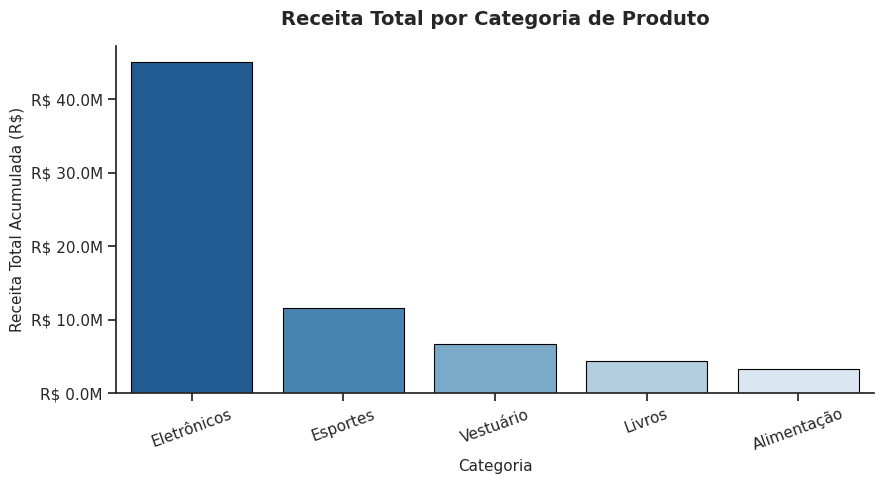

In [12]:
sns.set_theme(style="ticks", palette="muted")

df_cat_receita = df.groupby('categoria', as_index=False)['receita_total'].sum()
df_cat_receita = df_cat_receita.sort_values(by='receita_total', ascending=False)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=df_cat_receita,
    x='categoria',
    y='receita_total',
    palette='Blues_r',
    edgecolor='black',
    linewidth=0.8
)

plt.title('Receita Total por Categoria de Produto', fontsize=14, weight='bold', pad=15)
plt.xlabel('Categoria', fontsize=11)
plt.ylabel('Receita Total Acumulada (R$)', fontsize=11)
plt.xticks(rotation=20)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'R$ {x*1e-6:.1f}M'))
sns.despine()
plt.tight_layout()
plt.show()

O gráfico mostra os eletrônicos concentram a maior parte do faturamento com uma margem grande, depois vem esportes e com faturamentos mais baixos temos os segmentos de vestuário, livros e alimentação.

### B) Gráfico de Linha - Evolução Temporal da Receita Mensal

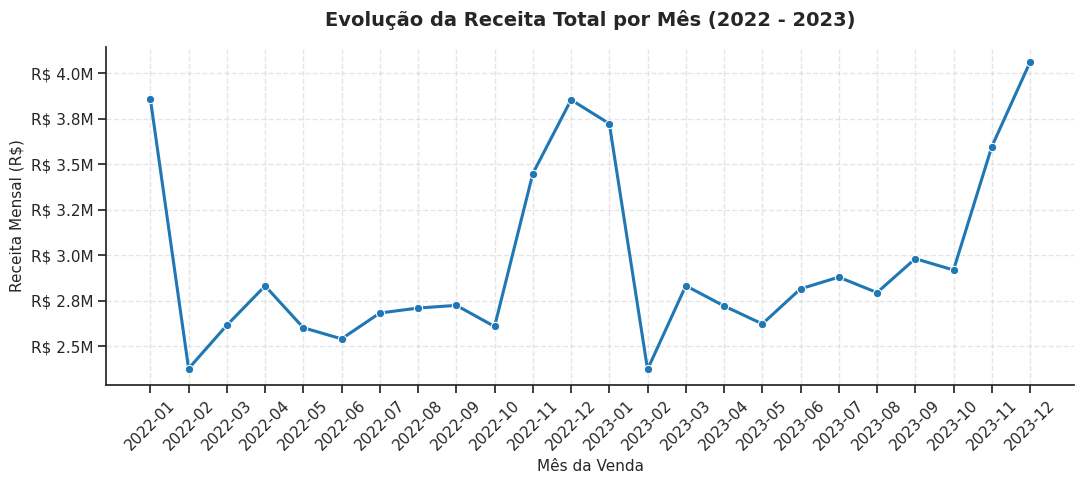

In [13]:
# Cria período mensal ordenado
df_mensal = df.copy()
df_mensal['ano_mes'] = df_mensal['data_venda'].dt.to_period('M').astype(str)
evolucao_receita = df_mensal.groupby('ano_mes', as_index=False)['receita_total'].sum()

plt.figure(figsize=(11, 5))
ax = sns.lineplot(
    data=evolucao_receita,
    x='ano_mes',
    y='receita_total',
    marker='o',
    color='#1f77b4',
    linewidth=2.2,
    markersize=6
)

plt.title('Evolução da Receita Total por Mês (2022 - 2023)', fontsize=14, weight='bold', pad=15)
plt.xlabel('Mês da Venda', fontsize=11)
plt.ylabel('Receita Mensal (R$)', fontsize=11)
plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'R$ {x*1e-6:.1f}M'))
plt.grid(True, linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
plt.show()

Nessa evolução, vemos que há um grande pico de vendas nos meses de Black Friday e compras de final de ano.

### C) Gráfico de Dispersão - Preço Unitário vs. Receita Total (Usando Amostras)

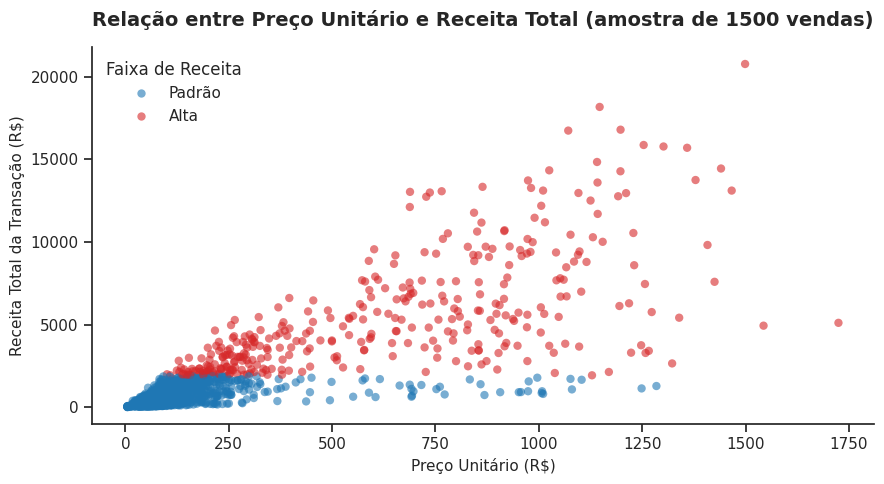

In [14]:
np.random.seed(42)
df_amostra = df.sample(n=1500)

plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df_amostra,
    x='preco_unitario',
    y='receita_total',
    hue='faixa_receita',
    alpha=0.6,
    palette={'Alta': '#d62728', 'Padrão': '#1f77b4'},
    edgecolor='none'
)

plt.title('Relação entre Preço Unitário e Receita Total (amostra de 1500 vendas)', fontsize=14, weight='bold', pad=15)
plt.xlabel('Preço Unitário (R$)', fontsize=11)
plt.ylabel('Receita Total da Transação (R$)', fontsize=11)
plt.legend(title='Faixa de Receita', frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

O gráfico mostra uma forte concentração de transações com preços unitários inferiores a 250 e receitas abaixo de 2.000 (faixa Padrão). Conforme o preço unitário aumenta, a receita dispersa-se e atinge valores acima de 15.000 (faixa Alta), demonstrando o impacto do valor unitário do artigo e da quantidade encomendada na receita total.

### D) Mapa de Calor - Matriz de Correlação entre Variáveis Numéricas

---



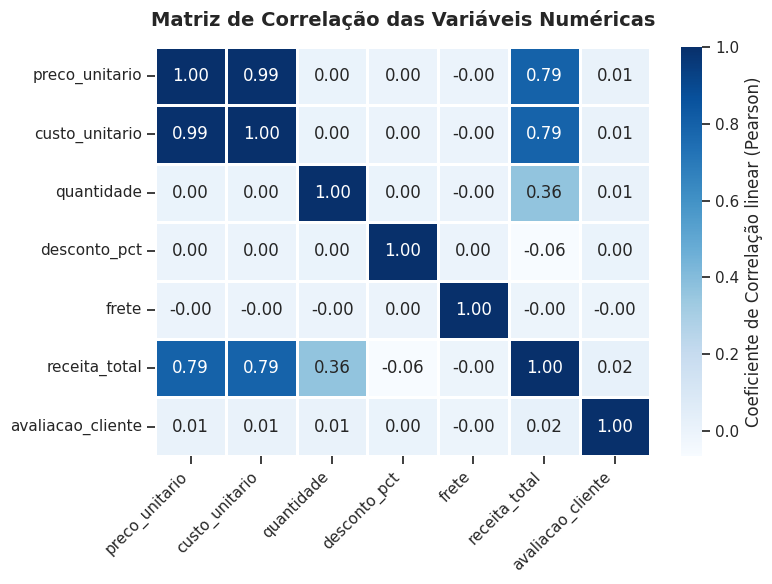

In [15]:
colunas_correlacao = [
    'preco_unitario', 'custo_unitario', 'quantidade',
    'desconto_pct', 'frete', 'receita_total', 'avaliacao_cliente'
]

matriz_corr = df[colunas_correlacao].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_corr,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    linewidths=0.8,
    linecolor='white',
    cbar_kws={'label': 'Coeficiente de Correlação linear (Pearson)'}
)

plt.title('Matriz de Correlação das Variáveis Numéricas', fontsize=14, weight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

O mapa de calor evidencia uma correlação positiva quase perfeita entre preco_unitario e custo_unitario (0,99), além de forte associação de ambos com a receita_total (0,79). Por outro lado, variáveis como avaliacao_cliente, frete e desconto_pct apresentam correlações próximas de zero com as demais métricas financeiras, indicando independência linear em relação ao faturamento das vendas.   

### Conclusão 

Analisando esses quatro gráficos do Entregável 3, vemos que o faturamento é concentrado no segmento de Eletrónicos e influenciado por picos sazonais no final de cada ano. A receita por transação depende principalmente do preço unitário e da quantidade de artigos, enquanto métricas como frete, desconto e avaliação do cliente atuam de forma independente do valor faturado.